In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Specify the path to your dataset in Google Drive
# Replace 'path/to/your/dataset.csv' with the actual path to your file
dataset_path = 'housing.csv'

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(dataset_path)
    # Display the first 5 rows of the DataFrame
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file was not found at {dataset_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np

# Check for missing values
print("Missing values before handling:")
display(df.isnull().sum())

# Handle missing values in 'total_bedrooms' by filling with the median
if df['total_bedrooms'].isnull().sum() > 0:
    imputer = SimpleImputer(strategy='median')
    df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])

print("\nMissing values after handling:")
display(df.isnull().sum())

# Select features and target variable
# Drop the 'ocean_proximity' column for now as it's a categorical feature
X = df.drop(['median_house_value', 'ocean_proximity'], axis=1)
y = df['median_house_value']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nShape of training data (X_train, y_train):")
print(X_train.shape, y_train.shape)
print("\nShape of testing data (X_test, y_test):")
print(X_test.shape, y_test.shape)

Missing values before handling:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0



Missing values after handling:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0



Shape of training data (X_train, y_train):
(16512, 8) (16512,)

Shape of testing data (X_test, y_test):
(4128, 8) (4128,)


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Instantiate a LinearRegression model
linear_reg_model = LinearRegression()

# Train the linear regression model
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_linear = linear_reg_model.predict(X_test)

# Calculate Mean Squared Error
mse_linear = mean_squared_error(y_test, y_pred_linear)

# Calculate R-squared score
r2_linear = r2_score(y_test, y_pred_linear)

# Print the evaluation metrics
print(f"Linear Regression - Mean Squared Error: {mse_linear:.2f}")
print(f"Linear Regression - R-squared Score: {r2_linear:.2f}")

Linear Regression - Mean Squared Error: 5059928371.17
Linear Regression - R-squared Score: 0.61


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create polynomial features
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# Instantiate a LinearRegression model for polynomial regression
poly_reg_model = LinearRegression()

# Train the polynomial regression model
poly_reg_model.fit(X_train_poly, y_train)

# Make predictions on the test data
y_pred_poly = poly_reg_model.predict(X_test_poly)

# Calculate Mean Squared Error for polynomial regression
mse_poly = mean_squared_error(y_test, y_pred_poly)

# Calculate R-squared score for polynomial regression
r2_poly = r2_score(y_test, y_pred_poly)

# Print the evaluation metrics
print(f"Polynomial Regression - Mean Squared Error: {mse_poly:.2f}")
print(f"Polynomial Regression - R-squared Score: {r2_poly:.2f}")

Polynomial Regression - Mean Squared Error: 4658060308.63
Polynomial Regression - R-squared Score: 0.64


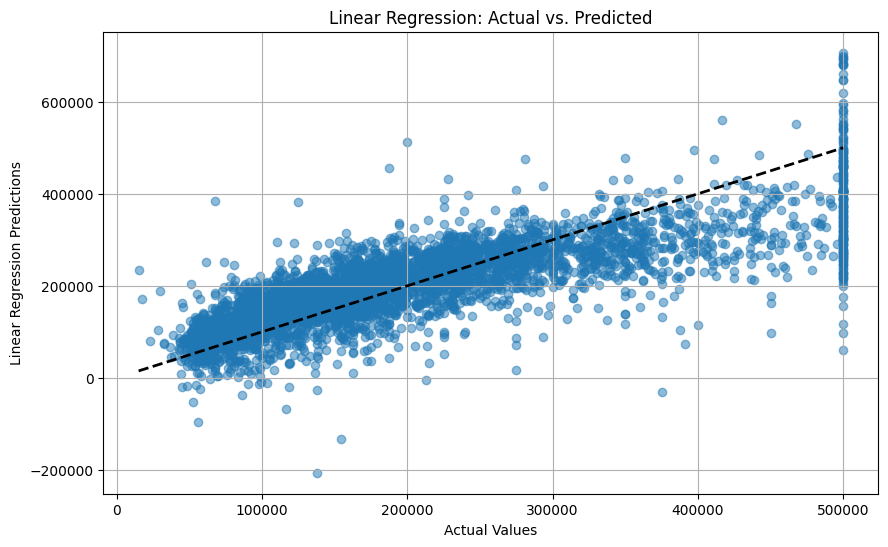

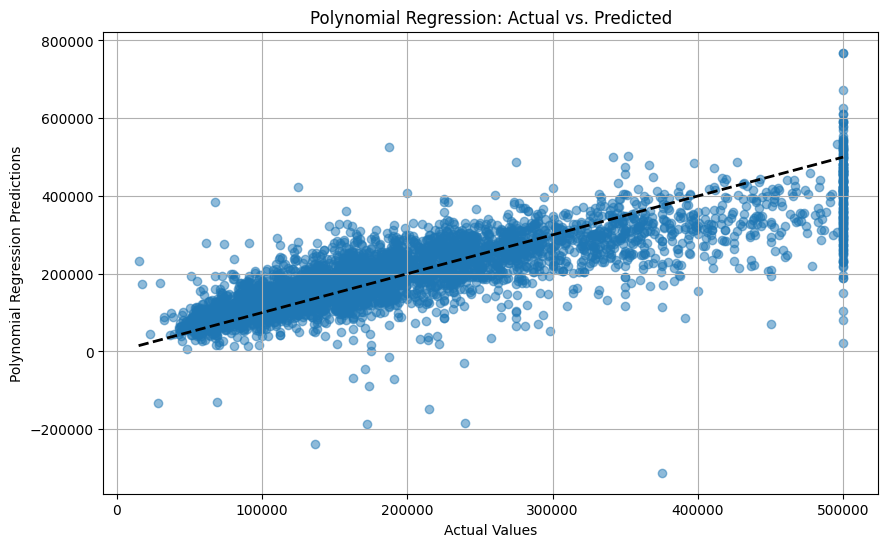

In [7]:
import matplotlib.pyplot as plt

# Create scatter plot for Linear Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Linear Regression Predictions")
plt.title("Linear Regression: Actual vs. Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line
plt.grid(True)
plt.show()

# Create scatter plot for Polynomial Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Polynomial Regression Predictions")
plt.title("Polynomial Regression: Actual vs. Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line
plt.grid(True)
plt.show()

In [8]:
# Print the evaluation metrics for Linear Regression
print("Linear Regression Performance:")
print(f"  Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"  R-squared Score: {r2_linear:.2f}")

print("\nPolynomial Regression Performance:")
print(f"  Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"  R-squared Score: {r2_poly:.2f}")

# Interpret the metrics and compare the models
print("\nInterpretation and Comparison:")
print("Mean Squared Error (MSE) measures the average of the squares of the errors—that is, the average squared difference between the estimated values and the actual value.")
print("A lower MSE indicates that the model's predictions are closer to the actual values, suggesting better performance.")
print(f"In this case, the Polynomial Regression model has a lower MSE ({mse_poly:.2f}) compared to the Linear Regression model ({mse_linear:.2f}), indicating that it fits the data better.")

print("\nR-squared score (Coefficient of Determination) represents the proportion of the variance in the dependent variable that is predictable from the independent variables.")
print("A higher R-squared score indicates that a larger proportion of the variance in the target variable is explained by the model, suggesting a better fit.")
print(f"The Polynomial Regression model has a higher R-squared score ({r2_poly:.2f}) than the Linear Regression model ({r2_linear:.2f}), which means it explains more of the variance in the housing values.")

print("\nConclusion:")
print("Based on both the MSE and R-squared metrics, the Polynomial Regression model (with degree 2) appears to perform better than the Linear Regression model on this dataset.")

Linear Regression Performance:
  Mean Squared Error (MSE): 5059928371.17
  R-squared Score: 0.61

Polynomial Regression Performance:
  Mean Squared Error (MSE): 4658060308.63
  R-squared Score: 0.64

Interpretation and Comparison:
Mean Squared Error (MSE) measures the average of the squares of the errors—that is, the average squared difference between the estimated values and the actual value.
A lower MSE indicates that the model's predictions are closer to the actual values, suggesting better performance.
In this case, the Polynomial Regression model has a lower MSE (4658060308.63) compared to the Linear Regression model (5059928371.17), indicating that it fits the data better.

R-squared score (Coefficient of Determination) represents the proportion of the variance in the dependent variable that is predictable from the independent variables.
A higher R-squared score indicates that a larger proportion of the variance in the target variable is explained by the model, suggesting a bette

In [9]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Instantiate a Ridge model
ridge_reg_model = Ridge()

# Train the Ridge model
ridge_reg_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_ridge = ridge_reg_model.predict(X_test)

# Calculate Mean Squared Error for Ridge regression
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# Calculate R-squared score for Ridge regression
r2_ridge = r2_score(y_test, y_pred_ridge)

# Print the evaluation metrics
print(f"Ridge Regression - Mean Squared Error: {mse_ridge:.2f}")
print(f"Ridge Regression - R-squared Score: {r2_ridge:.2f}")

Ridge Regression - Mean Squared Error: 5059900216.43
Ridge Regression - R-squared Score: 0.61


In [10]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Instantiate a Lasso object
lasso_reg_model = Lasso()

# Train the Lasso model
lasso_reg_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lasso = lasso_reg_model.predict(X_test)

# Calculate Mean Squared Error
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# Calculate R-squared score
r2_lasso = r2_score(y_test, y_pred_lasso)

# Print the evaluation metrics
print(f"Lasso Regression - Mean Squared Error: {mse_lasso:.2f}")
print(f"Lasso Regression - R-squared Score: {r2_lasso:.2f}")

Lasso Regression - Mean Squared Error: 5059916523.38
Lasso Regression - R-squared Score: 0.61


In [11]:
# Print the evaluation metrics for Linear Regression
print("Linear Regression Performance:")
print(f"  Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"  R-squared Score: {r2_linear:.2f}")

# Print the evaluation metrics for Ridge Regression
print("\nRidge Regression Performance:")
print(f"  Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"  R-squared Score: {r2_ridge:.2f}")

# Print the evaluation metrics for Lasso Regression
print("\nLasso Regression Performance:")
print(f"  Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"  R-squared Score: {r2_lasso:.2f}")

Linear Regression Performance:
  Mean Squared Error (MSE): 5059928371.17
  R-squared Score: 0.61

Ridge Regression Performance:
  Mean Squared Error (MSE): 5059900216.43
  R-squared Score: 0.61

Lasso Regression Performance:
  Mean Squared Error (MSE): 5059916523.38
  R-squared Score: 0.61


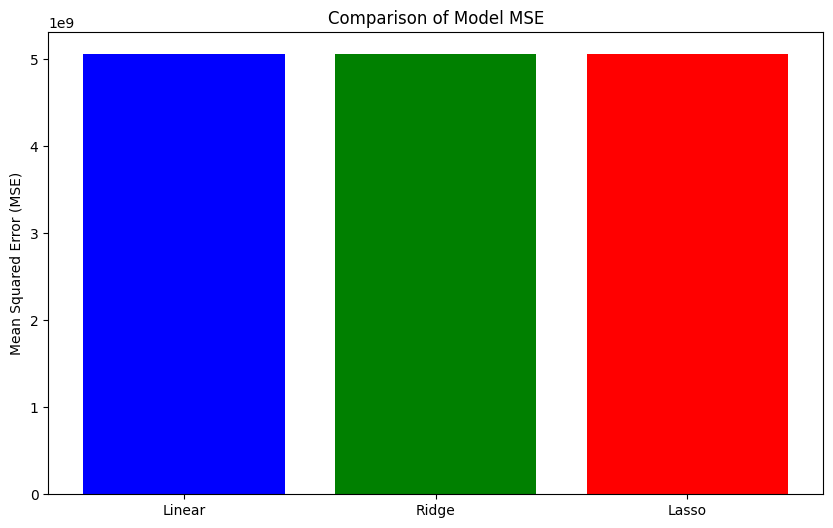

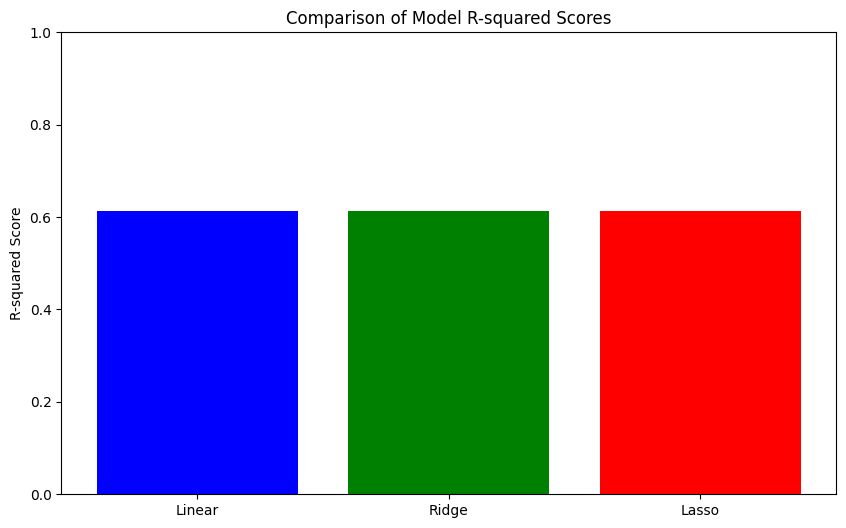


Interpretation of Comparison Results:
Mean Squared Error (MSE):
- Lower MSE indicates better model performance.
- Linear Regression MSE: 5059928371.17
- Ridge Regression MSE: 5059900216.43
- Lasso Regression MSE: 5059916523.38
All three models have very similar MSE values, with Ridge having a slightly lower MSE.

R-squared Score:
- Higher R-squared score indicates that more of the variance in the target variable is explained by the model.
- Linear Regression R2: 0.61
- Ridge Regression R2: 0.61
- Lasso Regression R2: 0.61
All three models also have very similar R-squared scores.

Conclusion:
Based on the Mean Squared Error and R-squared scores, the Linear, Ridge, and Lasso regression models perform very similarly on this dataset. Ridge regression shows a marginal improvement in MSE.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data for bar charts
models = ['Linear', 'Ridge', 'Lasso']
mse_values = [mse_linear, mse_ridge, mse_lasso]
r2_values = [r2_linear, r2_ridge, r2_lasso]

# Create MSE bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, mse_values, color=['blue', 'green', 'red'])
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Comparison of Model MSE')
plt.show()

# Create R-squared bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, r2_values, color=['blue', 'green', 'red'])
plt.ylabel('R-squared Score')
plt.title('Comparison of Model R-squared Scores')
plt.ylim(0, 1) # R-squared is between 0 and 1
plt.show()

# Interpret the comparison results
print("\nInterpretation of Comparison Results:")
print("Mean Squared Error (MSE):")
print(f"- Lower MSE indicates better model performance.")
print(f"- Linear Regression MSE: {mse_linear:.2f}")
print(f"- Ridge Regression MSE: {mse_ridge:.2f}")
print(f"- Lasso Regression MSE: {mse_lasso:.2f}")
print("All three models have very similar MSE values, with Ridge having a slightly lower MSE.")

print("\nR-squared Score:")
print(f"- Higher R-squared score indicates that more of the variance in the target variable is explained by the model.")
print(f"- Linear Regression R2: {r2_linear:.2f}")
print(f"- Ridge Regression R2: {r2_ridge:.2f}")
print(f"- Lasso Regression R2: {r2_lasso:.2f}")
print("All three models also have very similar R-squared scores.")

print("\nConclusion:")
print("Based on the Mean Squared Error and R-squared scores, the Linear, Ridge, and Lasso regression models perform very similarly on this dataset. Ridge regression shows a marginal improvement in MSE.")